# Uniform HSBM rho_n sweep with Zhou theta

This notebook keeps the uniform HSBM hyperparameters fixed and varies only `rho_n`.

Fixed parameters are `n`, `K`, `m`, `a_in`, `b_out`, sampling mode, row-normalization, eigensolver tolerance, and repetitions. For each `rho_n`, the model uses

`p_in = a_in * rho_n / n ** (m - 1)` and `p_out = b_out * rho_n / n ** (m - 1)`.

Spectral clustering uses the Zhou operator `Theta = I - Delta` and takes the eigenvectors associated with the largest eigenvalues of `Theta`, which is equivalent to taking the smallest eigenvalues of `Delta = I - Theta`.


In [1]:
from pathlib import Path
import gc
import json
import sys
import time
import tracemalloc
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

PROJECT_ROOT = Path.cwd()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "src" / "common.py").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find project root containing src/common.py")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.common import (
    generate_planted_uniform_hsbm_instance,
    normalize_rows_l2,
    zhou_normalized_laplacian,
)

EXPERIMENT_ID = "EXP-20260427-001"
EXPERIMENT_SLUG = "uniform_hsbm_rho_n_sweep_zhou_theta"
OUTDIR = PROJECT_ROOT / "experiments" / "균일 HSBM 실험" / "results" / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}"
OUTDIR.mkdir(parents=True, exist_ok=True)

EXPERIMENT_ID, EXPERIMENT_SLUG, PROJECT_ROOT, OUTDIR


('EXP-20260427-001',
 'uniform_hsbm_rho_n_sweep_zhou_theta',
 PosixPath('/Users/eomjeonghyeon/Documents/github_project/python-rand-nla-research'),
 PosixPath('/Users/eomjeonghyeon/Documents/github_project/python-rand-nla-research/experiments/균일 HSBM 실험/results/EXP-20260427-001_uniform_hsbm_rho_n_sweep_zhou_theta'))

## Configuration

Only `rho_n` is varied. All other model and algorithm parameters are fixed.


In [2]:
CONFIG = {
    "n": 10_000,
    "K": 3,
    "m": 3,
    "a_in": 36.0,
    "b_out": 4.0,
    "reps": 10,
    "seed": 20260427,
    "sampling": "sparse",
    "max_enumeration": 1_500_000,
    "normalize_embedding_rows": True,
    "eigsh_tol": 1e-6,
}

RHO_VALUES = [0.25, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0]

CONFIG, RHO_VALUES


({'n': 10000,
  'K': 3,
  'm': 3,
  'a_in': 36.0,
  'b_out': 4.0,
  'reps': 10,
  'seed': 20260427,
  'sampling': 'sparse',
  'max_enumeration': 1500000,
  'normalize_embedding_rows': True,
  'eigsh_tol': 1e-06},
 [0.25, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0])

## Helpers

In [3]:
def current_rss_mb():
    try:
        import psutil

        return psutil.Process().memory_info().rss / (1024.0 ** 2)
    except Exception:
        return np.nan


def measure_call(fn):
    gc.collect()
    rss_before_mb = current_rss_mb()
    tracemalloc.start()
    cpu_start = time.process_time()
    wall_start = time.perf_counter()
    value = fn()
    wall_clock_sec = time.perf_counter() - wall_start
    cpu_time_sec = time.process_time() - cpu_start
    current_bytes, peak_bytes = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    rss_after_mb = current_rss_mb()
    return value, {
        "cpu_time_sec": float(cpu_time_sec),
        "wall_clock_sec": float(wall_clock_sec),
        "peak_traced_memory_mb": float(peak_bytes / (1024.0 ** 2)),
        "rss_before_mb": float(rss_before_mb) if np.isfinite(rss_before_mb) else np.nan,
        "rss_after_mb": float(rss_after_mb) if np.isfinite(rss_after_mb) else np.nan,
        "rss_delta_mb": float(rss_after_mb - rss_before_mb)
        if np.isfinite(rss_before_mb) and np.isfinite(rss_after_mb)
        else np.nan,
    }


def aligned_misclassification_rate(y_true, y_pred, K):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    conf = np.zeros((K, K), dtype=int)
    for t, p in zip(y_true, y_pred):
        if 0 <= t < K and 0 <= p < K:
            conf[t, p] += 1
    true_ids, pred_ids = linear_sum_assignment(-conf)
    pred_to_true = {int(pred): int(true) for true, pred in zip(true_ids, pred_ids)}
    y_aligned = np.array([pred_to_true.get(int(p), int(p)) for p in y_pred], dtype=int)
    return float(np.mean(y_aligned != y_true)), y_aligned, conf


def hypergraph_vertex_degree_stats(n, hyperedges):
    degrees = np.zeros(int(n), dtype=float)
    for edge in hyperedges:
        for v in edge:
            degrees[int(v)] += 1.0
    return {
        "num_isolated_nodes": int(np.sum(degrees == 0)),
        "isolated_fraction": float(np.mean(degrees == 0)) if n > 0 else 0.0,
        "hypergraph_degree_mean": float(degrees.mean()) if n > 0 else 0.0,
        "hypergraph_degree_max": float(degrees.max()) if n > 0 else 0.0,
    }


def spectral_cluster_from_zhou_theta(theta, K, rng, normalize_rows=True, eigsh_tol=1e-6):
    n = int(theta.shape[0])
    theta = ((theta + theta.T) * 0.5).tocsr()
    total_start = time.perf_counter()
    timings = {}

    t0 = time.perf_counter()
    if n <= K + 1:
        vals, vecs = np.linalg.eigh(theta.toarray())
        order = np.argsort(vals)[-K:][::-1]
        U = vecs[:, order]
    else:
        try:
            v0 = rng.normal(size=n)
            vals, vecs = spla.eigsh(theta, k=K, which="LA", tol=eigsh_tol, v0=v0)
            order = np.argsort(vals)[::-1]
            U = vecs[:, order]
        except Exception as exc:
            warnings.warn(f"eigsh failed ({exc}); falling back to dense eigh.")
            vals, vecs = np.linalg.eigh(theta.toarray())
            order = np.argsort(vals)[-K:][::-1]
            U = vecs[:, order]
    timings["eigen_decomposition_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    if normalize_rows:
        U = normalize_rows_l2(U)
    timings["embedding_normalize_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    random_state = int(rng.integers(1, 2**31 - 1))
    labels = KMeans(n_clusters=K, n_init=20, random_state=random_state).fit_predict(U)
    timings["kmeans_wall_sec"] = time.perf_counter() - t0
    timings["spectral_clustering_wall_sec"] = time.perf_counter() - total_start
    return labels, {
        "zhou_theta_nnz": int(theta.nnz),
        **timings,
    }


def run_one_rep(rho_n, rep, config):
    n = int(config["n"])
    K = int(config["K"])
    m = int(config["m"])
    rho_n = float(rho_n)
    seed = int(config["seed"] + 1_000_003 * int(round(rho_n * 1_000_000)) + int(rep))
    rng = np.random.default_rng(seed)
    timings = {}

    t0 = time.perf_counter()
    hyperedges, y_true, Theta_true, gen_stats = generate_planted_uniform_hsbm_instance(
        n=n,
        K=K,
        d=m,
        a_d=float(config["a_in"]),
        b_d=float(config["b_out"]),
        rho_n=rho_n,
        rng=rng,
        sampling=config["sampling"],
        max_enumeration=int(config["max_enumeration"]),
        clip=False,
    )
    p_in = float(gen_stats["p_in"])
    p_out = float(gen_stats["p_out"])
    timings["generation_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    L = zhou_normalized_laplacian(n=n, hyperedges=hyperedges)
    theta = (sp.eye(n, format="csr", dtype=float) - L).tocsr()
    theta.eliminate_zeros()
    timings["zhou_theta_build_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    y_pred, spectral_stats = spectral_cluster_from_zhou_theta(
        theta=theta,
        K=K,
        rng=rng,
        normalize_rows=bool(config["normalize_embedding_rows"]),
        eigsh_tol=float(config["eigsh_tol"]),
    )
    timings["spectral_clustering_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    mis, y_aligned, conf = aligned_misclassification_rate(y_true, y_pred, K)
    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    timings["metric_wall_sec"] = time.perf_counter() - t0

    record = {
        "n": n,
        "rho_n": rho_n,
        "rep": int(rep),
        "seed": seed,
        "K": K,
        "m": m,
        "num_hyperedges_total": int(len(hyperedges)),
        "misclassification_rate": mis,
        "ARI": float(ari),
        "NMI": float(nmi),
        **timings,
        **hypergraph_vertex_degree_stats(n, hyperedges),
        **spectral_stats,
    }
    record["algorithm_total_wall_sec"] = float(
        record["generation_wall_sec"]
        + record["zhou_theta_build_wall_sec"]
        + record["eigen_decomposition_wall_sec"]
        + record["embedding_normalize_wall_sec"]
        + record["kmeans_wall_sec"]
    )
    record["p_in"] = float(p_in)
    record["p_out"] = float(p_out)
    record["sampling_mode"] = gen_stats.get("sampling_mode", "")
    return record


def run_one_rep_measured(rho_n, rep, config):
    record, measurement = measure_call(lambda: run_one_rep(rho_n=rho_n, rep=rep, config=config))
    record.update(measurement)
    return record


def run_rho_experiment(rho_n, reps=None, config=None):
    if config is None:
        config = CONFIG
    if reps is None:
        reps = int(config["reps"])

    rows = []
    for rep in range(1, reps + 1):
        row = run_one_rep_measured(rho_n=rho_n, rep=rep, config=config)
        rows.append(row)
        print(
            f"rho_n={rho_n:7.3f} rep={rep:2d}/{reps:<2d} "
            f"edges={row['num_hyperedges_total']:8d} "
            f"degree={row['hypergraph_degree_mean']:.2f} "
            f"isolated={row['isolated_fraction']:.4f} "
            f"mis={row['misclassification_rate']:.4f} "
            f"ARI={row['ARI']:.4f} NMI={row['NMI']:.4f} "
            f"wall={row['wall_clock_sec']:.3f}s "
            f"peak={row['peak_traced_memory_mb']:.1f}MB"
        )

    df = pd.DataFrame(rows)
    display(df)
    return df


def summarize_by_rho(df_raw):
    return df_raw.groupby("rho_n", as_index=False).agg(
        reps=("rep", "count"),
        hyperedges_mean=("num_hyperedges_total", "mean"),
        hyperedges_std=("num_hyperedges_total", "std"),
        degree_mean=("hypergraph_degree_mean", "mean"),
        degree_std=("hypergraph_degree_mean", "std"),
        isolated_fraction_mean=("isolated_fraction", "mean"),
        isolated_fraction_std=("isolated_fraction", "std"),
        misclassification_mean=("misclassification_rate", "mean"),
        misclassification_std=("misclassification_rate", "std"),
        ari_mean=("ARI", "mean"),
        ari_std=("ARI", "std"),
        nmi_mean=("NMI", "mean"),
        nmi_std=("NMI", "std"),
        generation_wall_sec_mean=("generation_wall_sec", "mean"),
        zhou_theta_build_wall_sec_mean=("zhou_theta_build_wall_sec", "mean"),
        eigen_decomposition_wall_sec_mean=("eigen_decomposition_wall_sec", "mean"),
        kmeans_wall_sec_mean=("kmeans_wall_sec", "mean"),
        spectral_clustering_wall_sec_mean=("spectral_clustering_wall_sec", "mean"),
        algorithm_total_wall_sec_mean=("algorithm_total_wall_sec", "mean"),
        cpu_time_sec_mean=("cpu_time_sec", "mean"),
        wall_clock_sec_mean=("wall_clock_sec", "mean"),
        peak_traced_memory_mb_mean=("peak_traced_memory_mb", "mean"),
        rss_delta_mb_mean=("rss_delta_mb", "mean"),
    )


## Run rho_n sweep

In [4]:
frames = []
for rho_n in RHO_VALUES:
    frames.append(run_rho_experiment(rho_n))

df_raw = pd.concat(frames, ignore_index=True)
summary = summarize_by_rho(df_raw)

display(summary)


rho_n=  0.250 rep= 1/10 edges=    3184 degree=0.96 isolated=0.3857 mis=0.6590 ARI=0.0002 NMI=0.0006 wall=0.626s peak=5.5MB
rho_n=  0.250 rep= 2/10 edges=    3069 degree=0.92 isolated=0.3999 mis=0.6617 ARI=0.0001 NMI=0.0004 wall=0.460s peak=5.5MB
rho_n=  0.250 rep= 3/10 edges=    3147 degree=0.94 isolated=0.3903 mis=0.6598 ARI=0.0001 NMI=0.0003 wall=0.447s peak=5.5MB
rho_n=  0.250 rep= 4/10 edges=    3117 degree=0.94 isolated=0.3976 mis=0.6626 ARI=-0.0000 NMI=0.0001 wall=0.366s peak=5.5MB
rho_n=  0.250 rep= 5/10 edges=    3203 degree=0.96 isolated=0.3876 mis=0.6571 ARI=0.0002 NMI=0.0005 wall=0.389s peak=5.5MB
rho_n=  0.250 rep= 6/10 edges=    3156 degree=0.95 isolated=0.3846 mis=0.6549 ARI=0.0002 NMI=0.0006 wall=0.408s peak=5.5MB
rho_n=  0.250 rep= 7/10 edges=    3197 degree=0.96 isolated=0.3832 mis=0.6634 ARI=-0.0001 NMI=0.0000 wall=0.397s peak=5.5MB
rho_n=  0.250 rep= 8/10 edges=    3085 degree=0.93 isolated=0.4004 mis=0.6566 ARI=0.0002 NMI=0.0005 wall=0.304s peak=5.5MB
rho_n=  0.250 

,n,rho_n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,...,algorithm_total_wall_sec,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,10000,0.25,1,250021010428,3,3,3184,0.6590,0.000244,0.000563,...,0.576354,9.000000e-08,1.000000e-08,sparse,3.051751,0.625775,5.528504,249.781250,264.531250,14.750000
1,10000,0.25,2,250021010429,3,3,3069,0.6617,0.000103,0.000401,...,0.411196,9.000000e-08,1.000000e-08,sparse,3.190744,0.459764,5.467441,264.546875,267.203125,2.656250
2,10000,0.25,3,250021010430,3,3,3147,0.6598,0.000078,0.000336,...,0.386569,9.000000e-08,1.000000e-08,sparse,2.375289,0.446990,5.499024,267.203125,269.921875,2.718750
3,10000,0.25,4,250021010431,3,3,3117,0.6626,-0.000044,0.000099,...,0.309640,9.000000e-08,1.000000e-08,sparse,2.395586,0.365583,5.486243,269.921875,270.296875,0.375000
4,10000,0.25,5,250021010432,3,3,3203,0.6571,0.000234,0.000523,...,0.334916,9.000000e-08,1.000000e-08,sparse,2.107097,0.388564,5.519537,270.296875,273.671875,3.375000
5,10000,0.25,6,250021010433,3,3,3156,0.6549,0.000239,0.000570,...,0.354166,9.000000e-08,1.000000e-08,sparse,2.355237,0.408438,5.501915,273.671875,273.984375,0.312500
6,10000,0.25,7,250021010434,3,3,3197,0.6634,-0.000133,0.000037,...,0.353102,9.000000e-08,1.000000e-08,sparse,2.772177,0.397257,5.518131,273.984375,277.906250,3.921875
7,10000,0.25,8,250021010435,3,3,3085,0.6566,0.000154,0.000487,...,0.251165,9.000000e-08,1.000000e-08,sparse,2.001723,0.304254,5.474114,277.906250,281.078125,3.171875
8,10000,0.25,9,250021010436,3,3,3236,0.6569,0.000216,0.000427,...,0.364164,9.000000e-08,1.000000e-08,sparse,2.872013,0.418591,5.531717,281.078125,281.125000,0.046875
9,10000,0.25,10,250021010437,3,3,3210,0.6513,0.001375,0.002444,...,0.343159,9.000000e-08,1.000000e-08,sparse,2.715537,0.383858,5.522614,281.125000,281.171875,0.046875


rho_n=  0.500 rep= 1/10 edges=    6276 degree=1.88 isolated=0.1512 mis=0.6598 ARI=0.0000 NMI=0.0005 wall=0.576s peak=6.7MB
rho_n=  0.500 rep= 2/10 edges=    6373 degree=1.91 isolated=0.1484 mis=0.6595 ARI=0.0001 NMI=0.0007 wall=0.505s peak=6.7MB
rho_n=  0.500 rep= 3/10 edges=    6383 degree=1.91 isolated=0.1472 mis=0.6605 ARI=0.0000 NMI=0.0010 wall=0.517s peak=6.7MB
rho_n=  0.500 rep= 4/10 edges=    6189 degree=1.86 isolated=0.1616 mis=0.6521 ARI=0.0009 NMI=0.0023 wall=0.418s peak=6.7MB
rho_n=  0.500 rep= 5/10 edges=    6186 degree=1.86 isolated=0.1585 mis=0.6647 ARI=-0.0001 NMI=0.0001 wall=0.526s peak=6.7MB
rho_n=  0.500 rep= 6/10 edges=    6200 degree=1.86 isolated=0.1512 mis=0.6600 ARI=0.0000 NMI=0.0012 wall=0.562s peak=6.7MB
rho_n=  0.500 rep= 7/10 edges=    6233 degree=1.87 isolated=0.1524 mis=0.6645 ARI=-0.0001 NMI=0.0000 wall=0.404s peak=6.7MB
rho_n=  0.500 rep= 8/10 edges=    6136 degree=1.84 isolated=0.1624 mis=0.6568 ARI=0.0001 NMI=0.0018 wall=0.580s peak=6.6MB
rho_n=  0.500 

,n,rho_n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,...,algorithm_total_wall_sec,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,10000,0.5,1,500021760428,3,3,6276,0.6598,0.000034,0.000548,...,0.529207,1.800000e-07,2.000000e-08,sparse,4.068569,0.576213,6.692561,281.812500,282.921875,1.109375
1,10000,0.5,2,500021760429,3,3,6373,0.6595,0.000099,0.000721,...,0.442710,1.800000e-07,2.000000e-08,sparse,3.495288,0.504635,6.728300,282.921875,284.703125,1.781250
2,10000,0.5,3,500021760430,3,3,6383,0.6605,0.000047,0.000976,...,0.466388,1.800000e-07,2.000000e-08,sparse,3.328484,0.517202,6.731551,284.703125,285.171875,0.468750
3,10000,0.5,4,500021760431,3,3,6189,0.6521,0.000857,0.002318,...,0.365338,1.800000e-07,2.000000e-08,sparse,2.630654,0.418340,6.657728,285.171875,285.171875,0.000000
4,10000,0.5,5,500021760432,3,3,6186,0.6647,-0.000058,0.000112,...,0.473674,1.800000e-07,2.000000e-08,sparse,3.540547,0.526171,6.657777,285.171875,285.171875,0.000000
5,10000,0.5,6,500021760433,3,3,6200,0.6600,0.000038,0.001161,...,0.513525,1.800000e-07,2.000000e-08,sparse,4.006425,0.562267,6.666275,285.171875,285.703125,0.531250
6,10000,0.5,7,500021760434,3,3,6233,0.6645,-0.000051,0.000049,...,0.345424,1.800000e-07,2.000000e-08,sparse,2.684428,0.403518,6.677006,285.703125,287.234375,1.531250
7,10000,0.5,8,500021760435,3,3,6136,0.6568,0.000149,0.001771,...,0.534405,1.800000e-07,2.000000e-08,sparse,3.927668,0.580207,6.638893,287.234375,287.250000,0.015625
8,10000,0.5,9,500021760436,3,3,6285,0.6624,0.000058,0.000534,...,0.526819,1.800000e-07,2.000000e-08,sparse,4.037012,0.573460,6.695644,287.250000,287.250000,0.000000
9,10000,0.5,10,500021760437,3,3,6394,0.6567,0.000294,0.001122,...,0.385630,1.800000e-07,2.000000e-08,sparse,2.672764,0.453948,6.735277,287.250000,287.250000,0.000000


rho_n=  1.000 rep= 1/10 edges=   12558 degree=3.77 isolated=0.0216 mis=0.6623 ARI=0.0001 NMI=0.0020 wall=0.823s peak=9.0MB
rho_n=  1.000 rep= 2/10 edges=   12606 degree=3.78 isolated=0.0243 mis=0.6454 ARI=0.0018 NMI=0.0046 wall=0.814s peak=9.0MB
rho_n=  1.000 rep= 3/10 edges=   12392 degree=3.72 isolated=0.0259 mis=0.6530 ARI=0.0005 NMI=0.0031 wall=0.827s peak=8.9MB
rho_n=  1.000 rep= 4/10 edges=   12494 degree=3.75 isolated=0.0240 mis=0.6604 ARI=0.0001 NMI=0.0025 wall=0.825s peak=9.0MB
rho_n=  1.000 rep= 5/10 edges=   12624 degree=3.79 isolated=0.0221 mis=0.6615 ARI=0.0001 NMI=0.0014 wall=0.779s peak=9.0MB
rho_n=  1.000 rep= 6/10 edges=   12480 degree=3.74 isolated=0.0238 mis=0.6622 ARI=0.0000 NMI=0.0013 wall=0.678s peak=9.0MB
rho_n=  1.000 rep= 7/10 edges=   12558 degree=3.77 isolated=0.0257 mis=0.6614 ARI=0.0001 NMI=0.0024 wall=0.861s peak=9.0MB
rho_n=  1.000 rep= 8/10 edges=   12451 degree=3.74 isolated=0.0236 mis=0.6563 ARI=0.0003 NMI=0.0054 wall=0.730s peak=9.0MB
rho_n=  1.000 re

...

rho_n=  8.000 rep= 1/10 edges=  100620 degree=30.19 isolated=0.0000 mis=0.0008 ARI=0.9976 NMI=0.9939 wall=3.886s peak=51.5MB
rho_n=  8.000 rep= 2/10 edges=  100614 degree=30.18 isolated=0.0000 mis=0.0005 ARI=0.9985 NMI=0.9960 wall=4.035s peak=51.6MB
rho_n=  8.000 rep= 3/10 edges=  100840 degree=30.25 isolated=0.0000 mis=0.0009 ARI=0.9973 NMI=0.9933 wall=4.154s peak=51.7MB
rho_n=  8.000 rep= 4/10 edges=  100822 degree=30.25 isolated=0.0000 mis=0.0006 ARI=0.9982 NMI=0.9953 wall=4.070s peak=51.7MB
rho_n=  8.000 rep= 5/10 edges=  100446 degree=30.13 isolated=0.0000 mis=0.0008 ARI=0.9976 NMI=0.9940 wall=4.060s peak=51.5MB
rho_n=  8.000 rep= 6/10 edges=  100638 degree=30.19 isolated=0.0000 mis=0.0002 ARI=0.9994 NMI=0.9983 wall=3.887s peak=51.6MB
rho_n=  8.000 rep= 7/10 edges=  100611 degree=30.18 isolated=0.0000 mis=0.0008 ARI=0.9976 NMI=0.9939 wall=4.375s peak=51.6MB
rho_n=  8.000 rep= 8/10 edges=  101014 degree=30.30 isolated=0.0000 mis=0.0002 ARI=0.9994 NMI=0.9983 wall=3.974s peak=51.8MB


,n,rho_n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,...,algorithm_total_wall_sec,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,10000,8.0,1,8000044260428,3,3,100620,0.0008,0.997601,0.993918,...,3.466681,0.000003,3.200000e-07,sparse,6.047825,3.885960,51.545832,337.437500,357.140625,19.703125
1,10000,8.0,2,8000044260429,3,3,100614,0.0005,0.998500,0.995979,...,3.641309,0.000003,3.200000e-07,sparse,6.424031,4.035269,51.553495,351.140625,382.312500,31.171875
2,10000,8.0,3,8000044260430,3,3,100840,0.0009,0.997301,0.993262,...,3.735431,0.000003,3.200000e-07,sparse,6.249688,4.154273,51.668061,377.312500,391.406250,14.093750
3,10000,8.0,4,8000044260431,3,3,100822,0.0006,0.998201,0.995276,...,3.676910,0.000003,3.200000e-07,sparse,6.289702,4.069559,51.661556,388.406250,392.437500,4.031250
4,10000,8.0,5,8000044260432,3,3,100446,0.0008,0.997601,0.993996,...,3.687888,0.000003,3.200000e-07,sparse,6.358006,4.059722,51.457705,390.437500,391.546875,1.109375
5,10000,8.0,6,8000044260433,3,3,100638,0.0002,0.999400,0.998341,...,3.513515,0.000003,3.200000e-07,sparse,6.104950,3.887113,51.560887,390.546875,392.921875,2.375000
6,10000,8.0,7,8000044260434,3,3,100611,0.0008,0.997601,0.993918,...,3.999667,0.000003,3.200000e-07,sparse,7.092385,4.374582,51.551532,392.921875,391.781250,-1.140625
7,10000,8.0,8,8000044260435,3,3,101014,0.0002,0.999400,0.998341,...,3.593593,0.000003,3.200000e-07,sparse,6.301969,3.974095,51.756245,391.781250,400.687500,8.906250
8,10000,8.0,9,8000044260436,3,3,101058,0.0005,0.998500,0.995979,...,4.006885,0.000003,3.200000e-07,sparse,6.843486,4.398096,51.768972,400.687500,402.046875,1.359375
9,10000,8.0,10,8000044260437,3,3,100712,0.0004,0.998800,0.996809,...,3.604293,0.000003,3.200000e-07,sparse,6.451590,3.998987,51.597291,402.046875,415.468750,13.421875


rho_n= 16.000 rep= 1/10 edges=  201652 degree=60.50 isolated=0.0000 mis=0.0000 ARI=1.0000 NMI=1.0000 wall=7.924s peak=101.7MB
rho_n= 16.000 rep= 2/10 edges=  200702 degree=60.21 isolated=0.0000 mis=0.0000 ARI=1.0000 NMI=1.0000 wall=7.697s peak=101.3MB
rho_n= 16.000 rep= 3/10 edges=  201168 degree=60.35 isolated=0.0000 mis=0.0000 ARI=1.0000 NMI=1.0000 wall=7.762s peak=101.5MB
rho_n= 16.000 rep= 4/10 edges=  201382 degree=60.41 isolated=0.0000 mis=0.0000 ARI=1.0000 NMI=1.0000 wall=8.683s peak=101.6MB
rho_n= 16.000 rep= 5/10 edges=  201045 degree=60.31 isolated=0.0000 mis=0.0000 ARI=1.0000 NMI=1.0000 wall=7.449s peak=101.4MB
rho_n= 16.000 rep= 6/10 edges=  201323 degree=60.40 isolated=0.0000 mis=0.0000 ARI=1.0000 NMI=1.0000 wall=8.463s peak=101.6MB
rho_n= 16.000 rep= 7/10 edges=  201337 degree=60.40 isolated=0.0000 mis=0.0000 ARI=1.0000 NMI=1.0000 wall=8.449s peak=101.6MB
rho_n= 16.000 rep= 8/10 edges=  202345 degree=60.70 isolated=0.0000 mis=0.0000 ARI=1.0000 NMI=1.0000 wall=8.426s peak=

,n,rho_n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,...,algorithm_total_wall_sec,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,10000,16.0,1,16000068260428,3,3,201652,0.0,1.0,1.0,...,7.152773,0.000006,6.400000e-07,sparse,9.905391,7.924309,101.744096,412.468750,435.375000,22.906250
1,10000,16.0,2,16000068260429,3,3,200702,0.0,1.0,1.0,...,6.930625,0.000006,6.400000e-07,sparse,9.649145,7.696874,101.271239,422.578125,409.093750,-13.484375
2,10000,16.0,3,16000068260430,3,3,201168,0.0,1.0,1.0,...,7.058055,0.000006,6.400000e-07,sparse,10.258987,7.762224,101.490066,397.093750,451.406250,54.312500
3,10000,16.0,4,16000068260431,3,3,201382,0.0,1.0,1.0,...,7.967246,0.000006,6.400000e-07,sparse,11.374459,8.683194,101.590194,440.406250,458.156250,17.750000
4,10000,16.0,5,16000068260432,3,3,201045,0.0,1.0,1.0,...,6.741466,0.000006,6.400000e-07,sparse,9.680469,7.448622,101.429568,451.156250,489.734375,38.578125
5,10000,16.0,6,16000068260433,3,3,201323,0.0,1.0,1.0,...,7.740349,0.000006,6.400000e-07,sparse,11.193180,8.463331,101.568042,482.734375,502.250000,19.515625
6,10000,16.0,7,16000068260434,3,3,201337,0.0,1.0,1.0,...,7.716888,0.000006,6.400000e-07,sparse,11.056194,8.448743,101.574307,495.250000,503.109375,7.859375
7,10000,16.0,8,16000068260435,3,3,202345,0.0,1.0,1.0,...,7.702496,0.000006,6.400000e-07,sparse,11.239460,8.425927,102.085480,499.109375,521.593750,22.484375
8,10000,16.0,9,16000068260436,3,3,202162,0.0,1.0,1.0,...,7.641860,0.000006,6.400000e-07,sparse,10.853592,8.360516,101.995195,517.593750,527.437500,9.843750
9,10000,16.0,10,16000068260437,3,3,202103,0.0,1.0,1.0,...,7.653129,0.000006,6.400000e-07,sparse,10.956451,8.376275,101.956038,523.437500,533.140625,9.703125


,rho_n,reps,hyperedges_mean,hyperedges_std,degree_mean,degree_std,isolated_fraction_mean,isolated_fraction_std,misclassification_mean,misclassification_std,...,generation_wall_sec_mean,zhou_theta_build_wall_sec_mean,eigen_decomposition_wall_sec_mean,kmeans_wall_sec_mean,spectral_clustering_wall_sec_mean,algorithm_total_wall_sec_mean,cpu_time_sec_mean,wall_clock_sec_mean,peak_traced_memory_mb_mean,rss_delta_mb_mean
0,0.25,10,3160.4,55.785701,0.94812,0.016736,0.38959,0.007087,0.65833,0.003736,...,0.112070,0.010342,0.066337,0.179475,0.246036,0.368443,2.583715,0.419907,5.504924,3.137500
1,0.50,10,6265.5,92.288497,1.87965,0.027687,0.15324,0.005675,0.65970,0.003819,...,0.197796,0.015859,0.025472,0.219028,0.244662,0.458312,3.439184,0.511596,6.688101,0.543750
2,1.00,10,12496.9,99.700050,3.74907,0.029910,0.02414,0.001866,0.65817,0.005356,...,0.425244,0.028653,0.017722,0.235411,0.253279,0.707171,3.765938,0.782777,8.983787,1.500000
3,2.00,10,25107.6,141.957897,7.53228,0.042587,0.00061,0.000264,0.10240,0.002426,...,0.897175,0.060259,0.014293,0.130662,0.145077,1.102507,3.378542,1.239910,13.845627,1.070312
4,4.00,10,50310.0,249.213875,15.09300,0.074764,0.00000,0.000000,0.01696,0.001353,...,1.776250,0.104080,0.011159,0.089467,0.100724,1.981049,4.523690,2.202800,26.451657,2.931250
5,8.00,10,100737.5,193.621194,30.22125,0.058086,0.00000,0.000000,0.00057,0.000254,...,3.370239,0.215994,0.016795,0.089482,0.106389,3.692617,6.416363,4.083766,51.612158,9.503125
6,16.00,10,201521.9,533.339677,60.45657,0.160002,0.00000,0.000000,0.00000,0.000000,...,6.896711,0.440513,0.017722,0.075457,0.093268,7.430489,10.616733,8.159002,101.670423,18.946875


## Save results

In [5]:
raw_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_raw.csv"
summary_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_summary.csv"
config_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_config.json"

df_raw.to_csv(raw_path, index=False)
summary.to_csv(summary_path, index=False)
with config_path.open("w", encoding="utf-8") as f:
    json.dump({"CONFIG": CONFIG, "RHO_VALUES": RHO_VALUES}, f, indent=2)

raw_path, summary_path, config_path


(PosixPath('/Users/eomjeonghyeon/Documents/github_project/python-rand-nla-research/experiments/균일 HSBM 실험/results/EXP-20260427-001_uniform_hsbm_rho_n_sweep_zhou_theta/EXP-20260427-001_uniform_hsbm_rho_n_sweep_zhou_theta_raw.csv'),
 PosixPath('/Users/eomjeonghyeon/Documents/github_project/python-rand-nla-research/experiments/균일 HSBM 실험/results/EXP-20260427-001_uniform_hsbm_rho_n_sweep_zhou_theta/EXP-20260427-001_uniform_hsbm_rho_n_sweep_zhou_theta_summary.csv'),
 PosixPath('/Users/eomjeonghyeon/Documents/github_project/python-rand-nla-research/experiments/균일 HSBM 실험/results/EXP-20260427-001_uniform_hsbm_rho_n_sweep_zhou_theta/EXP-20260427-001_uniform_hsbm_rho_n_sweep_zhou_theta_config.json'))

## Plot

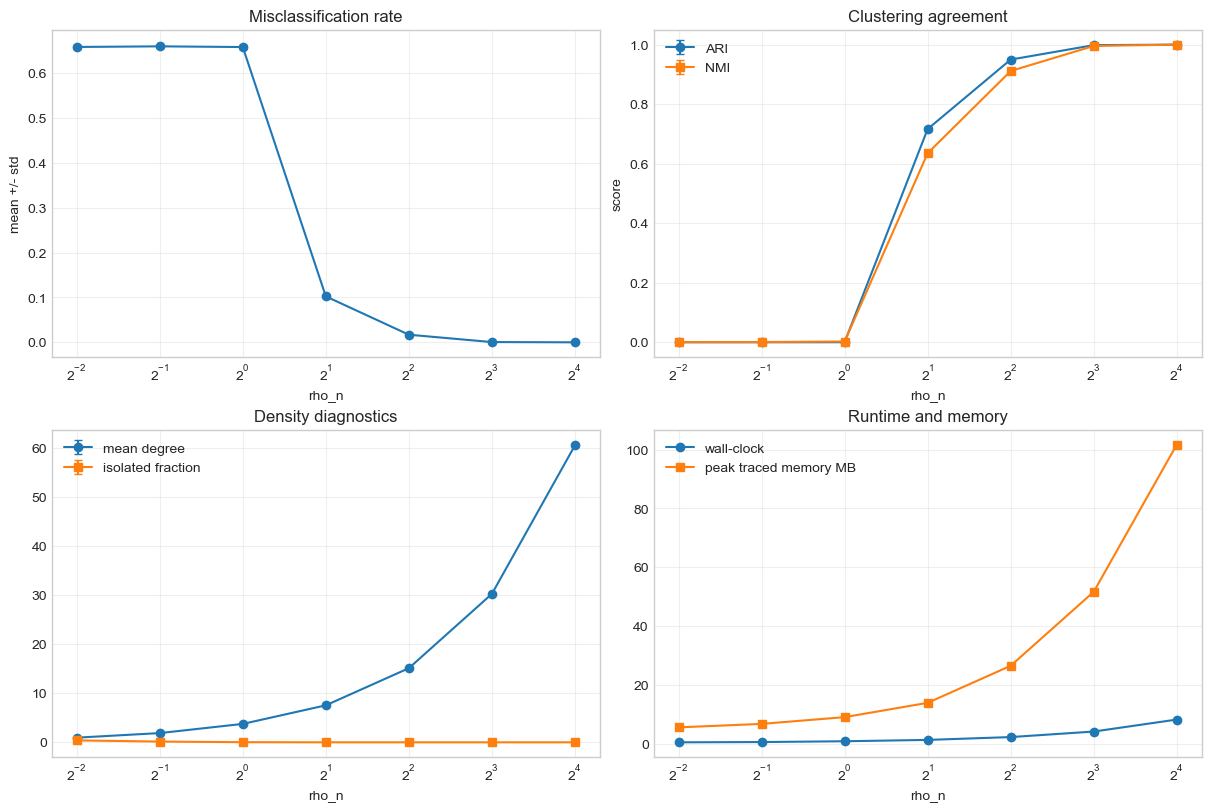

PosixPath('/Users/eomjeonghyeon/Documents/github_project/python-rand-nla-research/experiments/균일 HSBM 실험/results/EXP-20260427-001_uniform_hsbm_rho_n_sweep_zhou_theta/EXP-20260427-001_uniform_hsbm_rho_n_sweep_zhou_theta_summary.png')

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
x = summary["rho_n"].to_numpy()

axes[0, 0].errorbar(
    x,
    summary["misclassification_mean"],
    yerr=summary["misclassification_std"].fillna(0.0),
    marker="o",
    capsize=3,
)
axes[0, 0].set_xscale("log", base=2)
axes[0, 0].set_title("Misclassification rate")
axes[0, 0].set_xlabel("rho_n")
axes[0, 0].set_ylabel("mean +/- std")
axes[0, 0].grid(alpha=0.3)

axes[0, 1].errorbar(x, summary["ari_mean"], yerr=summary["ari_std"].fillna(0.0), marker="o", capsize=3, label="ARI")
axes[0, 1].errorbar(x, summary["nmi_mean"], yerr=summary["nmi_std"].fillna(0.0), marker="s", capsize=3, label="NMI")
axes[0, 1].set_xscale("log", base=2)
axes[0, 1].set_title("Clustering agreement")
axes[0, 1].set_xlabel("rho_n")
axes[0, 1].set_ylabel("score")
axes[0, 1].set_ylim(-0.05, 1.05)
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()

axes[1, 0].errorbar(x, summary["degree_mean"], yerr=summary["degree_std"].fillna(0.0), marker="o", capsize=3, label="mean degree")
axes[1, 0].errorbar(x, summary["isolated_fraction_mean"], yerr=summary["isolated_fraction_std"].fillna(0.0), marker="s", capsize=3, label="isolated fraction")
axes[1, 0].set_xscale("log", base=2)
axes[1, 0].set_title("Density diagnostics")
axes[1, 0].set_xlabel("rho_n")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()

axes[1, 1].errorbar(x, summary["wall_clock_sec_mean"], marker="o", capsize=3, label="wall-clock")
axes[1, 1].errorbar(x, summary["peak_traced_memory_mb_mean"], marker="s", capsize=3, label="peak traced memory MB")
axes[1, 1].set_xscale("log", base=2)
axes[1, 1].set_title("Runtime and memory")
axes[1, 1].set_xlabel("rho_n")
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

fig_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_summary.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()

fig_path
